In [1232]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [1233]:
df = pd.read_json("India-Food-Delivery-Time-Prediction.txt")

In [1234]:
print(df.head(10))

        ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  0x4607     INDORES13DEL02                  37.0                      4.9   
1  0xb379     BANGRES18DEL02                  34.0                      4.5   
2  0x5d6d     BANGRES19DEL01                  23.0                      4.4   
3  0x7a6a    COIMBRES13DEL02                  38.0                      4.7   
4  0x70a2     CHENRES12DEL01                  32.0                      4.6   
5  0x9bb4      HYDRES09DEL03                  22.0                      4.8   
6  0x95b4   RANCHIRES15DEL01                  33.0                      4.7   
7  0x9eb2      MYSRES15DEL02                  35.0                      4.6   
8  0x1102      HYDRES05DEL02                  22.0                      4.8   
9  0xcdcd      DEHRES17DEL01                  36.0                      4.2   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471          

In [1235]:
print(df.shape)

(41953, 20)


In [1236]:
print(df.columns)

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='str')


In [1237]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  str    
 1   Delivery_person_ID           41953 non-null  str    
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  str    
 9   Time_Orderd                  40353 non-null  str    
 10  Time_Order_picked            41953 non-null  str    
 11  Weatherconditions            41953 non-null  str    
 12  Road_traffic_density         41953 non-null  str    
 13  Vehicle_condition          

suspicious column id , delivery_person_age,ratings,time_ordered

suspicious data tye date,timeordered,taken

In [1238]:
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64


In [1239]:
print(df.duplicated().sum())

0


checking unique in every columns

In [1240]:
df["Festival"] = df["Festival"].str.strip()
df["City"] = df["City"].str.strip()
df["Weatherconditions"] = df["Weatherconditions"].str.strip()
df["Road_traffic_density"] = df["Road_traffic_density"].str.strip()

In [1241]:
print(df["Weatherconditions"].value_counts())


Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: count, dtype: int64


In [1242]:
print(df["Road_traffic_density"].value_counts())

Road_traffic_density
Low       14200
Jam       13043
Medium    10084
High       4071
NaN         555
Name: count, dtype: int64


In [1243]:
print(df["Type_of_order"].value_counts())

Type_of_order
Snack      10616
Meal       10524
Drinks     10445
Buffet     10368
Name: count, dtype: int64


In [1244]:
print(df["Type_of_vehicle"].value_counts())

Type_of_vehicle
motorcycle           24396
scooter              14029
electric_scooter      3468
bicycle                 60
Name: count, dtype: int64


In [1245]:
print(df["multiple_deliveries"].value_counts())

multiple_deliveries
1.0    25928
0.0    12952
2.0     1841
3.0      327
Name: count, dtype: int64


In [1246]:
print(df["Festival"].value_counts())

Festival
No     40916
Yes      822
NaN      215
Name: count, dtype: int64


In [1247]:
print(df["City"].value_counts())

City
Metropolitian    31411
Urban             9279
NaN               1114
Semi-Urban         149
Name: count, dtype: int64


In [1248]:
print(df["Delivery_person_Age"].describe())

count    40234.000000
mean        29.563330
std          5.812361
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64


In [1249]:
print(df["Delivery_person_Ratings"].describe())


count    40190.000000
mean         4.632386
std          0.335541
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64


In [1250]:
print(df["Restaurant_latitude"].describe())

count    41953.000000
mean        18.911397
std          5.467829
min          9.957144
25%         12.986047
50%         19.065838
75%         22.751234
max         30.914057
Name: Restaurant_latitude, dtype: float64


In [1251]:
print(df["Restaurant_longitude"].describe())

count    41953.000000
mean        76.923408
std          3.502910
min         72.768726
25%         73.898520
50%         76.618203
75%         78.368855
max         88.433452
Name: Restaurant_longitude, dtype: float64


In [1252]:
print(df["Delivery_location_latitude"].describe())


count    41953.000000
mean        18.975064
std          5.469616
min          9.967144
25%         13.065996
50%         19.123249
75%         22.820040
max         31.054057
Name: Delivery_location_latitude, dtype: float64


In [1253]:
print(df["Delivery_location_longitude"].describe())

count    41953.000000
mean        76.987074
std          3.503073
min         72.778726
25%         73.940327
50%         76.663622
75%         78.405467
max         88.563452
Name: Delivery_location_longitude, dtype: float64


In [1254]:
print(df["Order_Date"].value_counts().head(10))

Order_Date
15-03-2022    1115
03-04-2022    1101
13-03-2022    1095
26-03-2022    1093
05-04-2022    1091
24-03-2022    1091
09-03-2022    1088
11-03-2022    1079
05-03-2022    1079
21-03-2022    1079
Name: count, dtype: int64


In [1255]:
print(df["Time_Orderd"].value_counts().head(10))

Time_Orderd
20:32:38    8
19:56:41    8
19:21:37    7
21:16:49    7
19:02:56    7
22:59:06    7
17:37:32    7
23:31:23    7
21:42:35    7
18:11:06    7
Name: count, dtype: int64


In [1256]:
print(df["Time_Order_picked"].value_counts().head(10))

Time_Order_picked
0:00:12     8
19:34:34    8
17:30:15    8
21:56:46    8
18:43:15    7
23:13:17    7
23:49:44    7
21:31:21    7
23:45:29    7
18:41:55    7
Name: count, dtype: int64


In [1257]:
print(df["Vehicle_condition"].value_counts())

Vehicle_condition
1    13851
0    13815
2    13806
3      481
Name: count, dtype: int64


In [1258]:
print(df["Time_taken(min)"].value_counts().head(10))

Time_taken(min)
(min) 26    1960
(min) 25    1899
(min) 27    1826
(min) 29    1795
(min) 28    1794
(min) 19    1675
(min) 15    1645
(min) 18    1604
(min) 16    1579
(min) 17    1546
Name: count, dtype: int64


In [1259]:
print(df["ID"].nunique())

41953


In [1260]:
df["Delivery_person_ID"].nunique()

1170

In [1261]:
df["Time_taken(min)"].head()

0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
Name: Time_taken(min), dtype: str

removing min()from column

In [1262]:
df["Time_taken(min)"] = df["Time_taken(min)"].str.replace("(min) ", "")

In [1263]:
df["Time_taken(min)"].head()

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: str

In [1264]:
df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"])

In [1265]:
df["Time_taken(min)"].dtype

dtype('int64')

In [1266]:
df["multiple_deliveries"].describe()

count    41048.000000
mean         0.745249
std          0.572152
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: multiple_deliveries, dtype: float64

In [1267]:
print(df["Vehicle_condition"].describe())

count    41953.000000
mean         1.022716
std          0.838893
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Vehicle_condition, dtype: float64


In [1268]:
print(df["Time_taken(min)"].describe())

count    41953.000000
mean        26.311539
std          9.380753
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64


In [1269]:
print(df["Order_Date"].dtype)


str


In [1270]:
print(df["Order_Date"].head())


0    19-03-2022
1    25-03-2022
2    19-03-2022
3    05-04-2022
4    26-03-2022
Name: Order_Date, dtype: str


In [1271]:
print(df["Order_Date"].isnull().sum())

0


In [1272]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y")

In [1273]:
print(df["Order_Date"].head())

0   2022-03-19
1   2022-03-25
2   2022-03-19
3   2022-04-05
4   2022-03-26
Name: Order_Date, dtype: datetime64[us]


In [1274]:
print(df["Time_Orderd"].dtype)

str


In [1275]:
print(df["Time_Orderd"].head())

0    11:33:33
1    19:45:37
2     8:32:58
3    18:03:58
4    13:34:16
Name: Time_Orderd, dtype: str


In [1276]:
print(df["Time_Orderd"].isnull().sum())

1600


In [1277]:
print(df["Time_Order_picked"].dtype)

str


In [1278]:
print(df["Time_Order_picked"].isnull().sum())

0


problem found till now

* Delivery_person_Age → missing (1719), suspicious (age = 15)
* Delivery_person_Ratings → missing (1763), suspicious (rating = 6)
* Time_Orderd → missing (1600)
* multiple_deliveries → missing (905)
* Vehicle_condition → suspicious (condition = 3)

handled  

* Time_taken(min) → "(min)" prefix removed, converted to int
* Order_Date → converted from str to datetime
* Duplicate rows → 0 duplicates
* Restaurant_latitude → no issue
* Restaurant_longitude → no issue
* Delivery_location_latitude → no issue
* Delivery_location_longitude → no issue
* Time_Order_picked → no missing values
* Type_of_order → no issue
* Type_of_vehicle → no issue
* Festival → no major issue identified
* City → no major issue identified
* Weatherconditions → no major issue identified
* Road_traffic_density → no major issue identified

In [1279]:
print(df["Weatherconditions"].value_counts())

Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: count, dtype: int64


In [1280]:
print(df["Road_traffic_density"].value_counts())

Road_traffic_density
Low       14200
Jam       13043
Medium    10084
High       4071
NaN         555
Name: count, dtype: int64


In [1281]:
print(df["Type_of_order"].value_counts())

Type_of_order
Snack      10616
Meal       10524
Drinks     10445
Buffet     10368
Name: count, dtype: int64


In [1282]:
print(df["Type_of_vehicle"].value_counts())

Type_of_vehicle
motorcycle           24396
scooter              14029
electric_scooter      3468
bicycle                 60
Name: count, dtype: int64


In [1283]:
print(df["ID"].duplicated().sum())

0


In [1284]:
print(df["Delivery_person_ID"].duplicated().sum())

40783


sum up 

Age - missing + age 15
Ratings -missing + rating 6
Time_Orderd - missing
multiple_deliveries - missing
Weatherconditions - 569 "NaN"
Road_traffic_density - 555 "NaN"

In [1285]:
df = df.replace("NaN", pd.NA)

In [1286]:
df["Festival"] = df["Festival"].fillna(
    df["Festival"].mode()[0]
)

In [1287]:
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                           1114
Time_taken(min)                   0
dtype: int64


In [1288]:
print(df.describe())

       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
count         40234.000000             40190.000000         41953.000000   
mean             29.563330                 4.632386            18.911397   
min              15.000000                 1.000000             9.957144   
25%              25.000000                 4.500000            12.986047   
50%              30.000000                 4.700000            19.065838   
75%              35.000000                 4.900000            22.751234   
max              50.000000                 6.000000            30.914057   
std               5.812361                 0.335541             5.467829   

       Restaurant_longitude  Delivery_location_latitude  \
count          41953.000000                41953.000000   
mean              76.923408                   18.975064   
min               72.768726                    9.967144   
25%               73.898520                   13.065996   
50%               76

delivery person age handling


In [1289]:
df["Delivery_person_Age"] = df["Delivery_person_Age"].replace([15, 50], np.nan)
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].replace(
    6, np.nan
)
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median()
)

In [1290]:
df["Time_Orderd"] = pd.to_datetime(
    df["Time_Orderd"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Time_Order_picked"] = pd.to_datetime(
    df["Time_Order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)

avg_process_time = (
    df["Time_Order_picked"] - df["Time_Orderd"]
).mean()

df["Time_Orderd"] = df["Time_Orderd"].fillna(
    df["Time_Order_picked"] - avg_process_time
)

In [1291]:
df["Order_Hour"] = df["Time_Orderd"].dt.hour
df["Picked_Hour"] = df["Time_Order_picked"].dt.hour

In [1292]:
print(df["Time_Orderd"].dtype)

datetime64[us]


In [1293]:
print(df["Time_Orderd"].isnull().sum())

0


checking most common value

In [1294]:
print(df["multiple_deliveries"].mode())

0    1.0
Name: multiple_deliveries, dtype: float64


In [1295]:
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(df["multiple_deliveries"].mode()[0])

In [1296]:
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                       0
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                           1114
Time_taken(min)                   0
Order_Hour                        0
Picked_Hour                       0
dtype: int64


In [1297]:
print(df[df["Time_Orderd"].isnull()].head())

Empty DataFrame
Columns: [ID, Delivery_person_ID, Delivery_person_Age, Delivery_person_Ratings, Restaurant_latitude, Restaurant_longitude, Delivery_location_latitude, Delivery_location_longitude, Order_Date, Time_Orderd, Time_Order_picked, Weatherconditions, Road_traffic_density, Vehicle_condition, Type_of_order, Type_of_vehicle, multiple_deliveries, Festival, City, Time_taken(min), Order_Hour, Picked_Hour]
Index: []

[0 rows x 22 columns]


In [1298]:
print(df["Time_Orderd"].isnull().sum())

0


In [1299]:
print(df["Order_Date"].dtype)

datetime64[us]


In [1300]:
print(df["Order_Date"].min())

2022-02-11 00:00:00


In [1301]:
print(df["Order_Date"].max())

2022-04-06 00:00:00


In [1302]:
print(df["Order_Date"].nunique())

44


In [1303]:
print(df["Order_Date"].value_counts().head(10))

Order_Date
2022-03-15    1115
2022-04-03    1101
2022-03-13    1095
2022-03-26    1093
2022-04-05    1091
2022-03-24    1091
2022-03-09    1088
2022-03-11    1079
2022-03-05    1079
2022-03-21    1079
Name: count, dtype: int64


In [1304]:
print(df.describe())

       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
count         41953.000000             41953.000000         41953.000000   
mean             29.571807                 4.633802            18.911397   
min              20.000000                 1.000000             9.957144   
25%              25.000000                 4.500000            12.986047   
50%              30.000000                 4.700000            19.065838   
75%              34.000000                 4.800000            22.751234   
max              39.000000                 5.000000            30.914057   
std               5.636706                 0.325577             5.467829   

       Restaurant_longitude  Delivery_location_latitude  \
count          41953.000000                41953.000000   
mean              76.923408                   18.975064   
min               72.768726                    9.967144   
25%               73.898520                   13.065996   
50%               76

In [1305]:
print((df["Delivery_person_Age"] == 15).sum())


0


In [1306]:
print(df[df["Delivery_person_Age"] == 15].head(10))

Empty DataFrame
Columns: [ID, Delivery_person_ID, Delivery_person_Age, Delivery_person_Ratings, Restaurant_latitude, Restaurant_longitude, Delivery_location_latitude, Delivery_location_longitude, Order_Date, Time_Orderd, Time_Order_picked, Weatherconditions, Road_traffic_density, Vehicle_condition, Type_of_order, Type_of_vehicle, multiple_deliveries, Festival, City, Time_taken(min), Order_Hour, Picked_Hour]
Index: []

[0 rows x 22 columns]


checking for rating 6


In [1307]:
print((df["Delivery_person_Ratings"] == 6).sum())

0


In [1308]:
print(df[df["Delivery_person_Ratings"] == 6].head(10))

Empty DataFrame
Columns: [ID, Delivery_person_ID, Delivery_person_Age, Delivery_person_Ratings, Restaurant_latitude, Restaurant_longitude, Delivery_location_latitude, Delivery_location_longitude, Order_Date, Time_Orderd, Time_Order_picked, Weatherconditions, Road_traffic_density, Vehicle_condition, Type_of_order, Type_of_vehicle, multiple_deliveries, Festival, City, Time_taken(min), Order_Hour, Picked_Hour]
Index: []

[0 rows x 22 columns]


In [1309]:
print(df["Vehicle_condition"].value_counts())

Vehicle_condition
1    13851
0    13815
2    13806
3      481
Name: count, dtype: int64


In [1310]:
print(df["Vehicle_condition"].describe())

count    41953.000000
mean         1.022716
std          0.838893
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Vehicle_condition, dtype: float64


In [1311]:
print(df["multiple_deliveries"].value_counts())

multiple_deliveries
1.0    26833
0.0    12952
2.0     1841
3.0      327
Name: count, dtype: int64


In [1312]:
print(df["Time_taken(min)"].describe())

count    41953.000000
mean        26.311539
std          9.380753
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64


In [1313]:
print(df["Weatherconditions"].value_counts())

Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: count, dtype: int64


In [1314]:
print(df["Road_traffic_density"].value_counts())

Road_traffic_density
Low       14200
Jam       13043
Medium    10084
High       4071
Name: count, dtype: int64


In [1315]:
print(df["Festival"].value_counts())

Festival
No     41131
Yes      822
Name: count, dtype: int64


NOTE:- bht kam delivery pe festival pad rhe hai

In [1316]:
print(df["City"].value_counts())

City
Metropolitian    31411
Urban             9279
Semi-Urban         149
Name: count, dtype: int64


In [1317]:
print(df["Type_of_order"].value_counts())

Type_of_order
Snack      10616
Meal       10524
Drinks     10445
Buffet     10368
Name: count, dtype: int64


In [1318]:
print(df["Type_of_vehicle"].value_counts())

Type_of_vehicle
motorcycle           24396
scooter              14029
electric_scooter      3468
bicycle                 60
Name: count, dtype: int64


In [1319]:
print(df.groupby("Road_traffic_density")["Time_taken(min)"].mean())

Road_traffic_density
High      27.226480
Jam       31.183087
Low       21.279930
Medium    26.726497
Name: Time_taken(min), dtype: float64


In [1320]:
print(df.groupby("Weatherconditions")["Time_taken(min)"].mean())


Weatherconditions
conditions Cloudy        28.925995
conditions Fog           28.974330
conditions NaN           26.342707
conditions Sandstorms    25.880973
conditions Stormy        25.896759
conditions Sunny         21.897295
conditions Windy         26.128952
Name: Time_taken(min), dtype: float64


In [1321]:
print(df["Weatherconditions"].unique())

<StringArray>
[     'conditions Sunny',     'conditions Stormy', 'conditions Sandstorms',
     'conditions Cloudy',        'conditions Fog',      'conditions Windy',
        'conditions NaN']
Length: 7, dtype: str


In [1322]:
df["Weatherconditions"]=df["Weatherconditions"].str.replace("conditions ", "", regex=False)

In [1323]:
print(df["Weatherconditions"].isnull().sum())


0


In [1324]:
df["Weatherconditions"] = df["Weatherconditions"].replace("NaN", pd.NA)

In [1325]:
print(df["Weatherconditions"].isnull().sum())

569


In [1326]:
print(df["Weatherconditions"].value_counts(dropna=False))

Weatherconditions
Fog           7012
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
NaN            569
Name: count, dtype: int64


In [1327]:
print(df.groupby("Weatherconditions")["Time_taken(min)"].mean())

Weatherconditions
Cloudy        28.925995
Fog           28.974330
Sandstorms    25.880973
Stormy        25.896759
Sunny         21.897295
Windy         26.128952
Name: Time_taken(min), dtype: float64


In [1328]:
print(df.groupby("Type_of_vehicle")["Time_taken(min)"].mean())

Type_of_vehicle
bicycle              26.416667
electric_scooter     24.460208
motorcycle           27.609198
scooter              24.512153
Name: Time_taken(min), dtype: float64


In [1329]:
print(df.groupby("multiple_deliveries")["Time_taken(min)"].mean())

multiple_deliveries
0.0    22.896232
1.0    26.727500
2.0    40.450842
3.0    47.850153
Name: Time_taken(min), dtype: float64


In [1330]:
print(df.groupby("Festival")["Time_taken(min)"].mean())

Festival
No     25.928472
Yes    45.479319
Name: Time_taken(min), dtype: float64


In [1331]:
print(df.groupby("City")["Time_taken(min)"].mean())

City
Metropolitian    27.321225
Semi-Urban       49.677852
Urban            23.024895
Name: Time_taken(min), dtype: float64


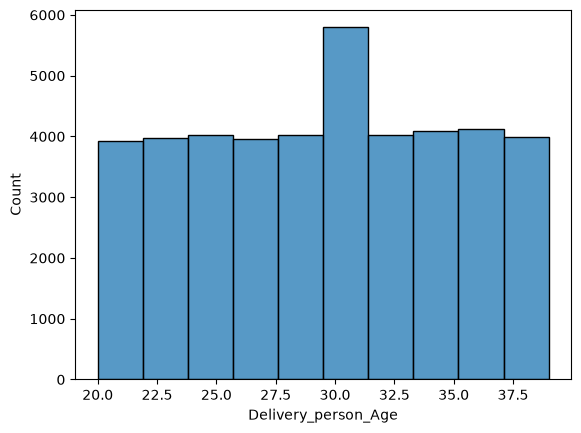

In [1332]:
sns.histplot(df["Delivery_person_Age"], bins=10)
plt.show()

In [1333]:
df["Age_group"] = pd.cut(
    df["Delivery_person_Age"],
    bins=[19, 24, 29, 34, 39, 50],
    labels=["20-24", "25-29", "30-34", "35-39", "40-50"]
)

In [1334]:
print(df[["Delivery_person_Age", "Age_group"]].head(10))

   Delivery_person_Age Age_group
0                 37.0     35-39
1                 34.0     30-34
2                 23.0     20-24
3                 38.0     35-39
4                 32.0     30-34
5                 22.0     20-24
6                 33.0     30-34
7                 35.0     35-39
8                 22.0     20-24
9                 36.0     35-39


In [1335]:
print(df.groupby("Age_group")["Time_taken(min)"].mean())

Age_group
20-24    23.023237
25-29    23.006919
30-34    29.094734
35-39    29.515889
Name: Time_taken(min), dtype: float64


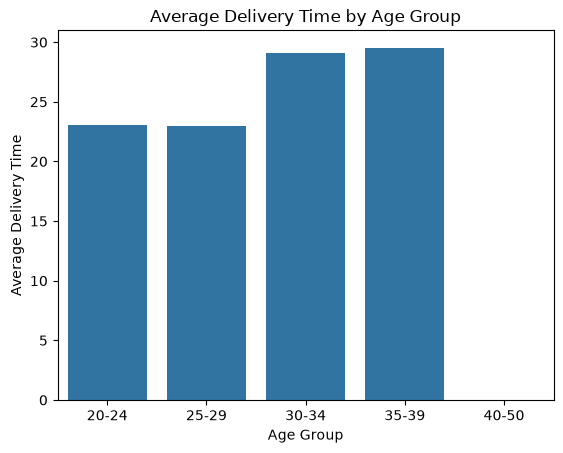

In [1336]:
sns.barplot(data=df, x="Age_group", y="Time_taken(min)", errorbar=None)
plt.xlabel("Age Group")
plt.ylabel("Average Delivery Time")
plt.title("Average Delivery Time by Age Group")
plt.show()

In [1337]:
print(df.groupby("Delivery_person_Ratings")["Time_taken(min)"].mean())

Delivery_person_Ratings
1.0    25.885714
2.5    36.722222
2.6    38.800000
2.7    36.095238
2.8    36.529412
2.9    38.222222
3.0    32.666667
3.1    36.750000
3.2    36.576923
3.3    36.434783
3.4    35.718750
3.5    37.059322
3.6    37.340206
3.7    37.315271
3.8    37.211009
3.9    37.517045
4.0    34.749499
4.1    34.538171
4.2    34.468069
4.3    34.505765
4.4    34.981541
4.5    23.638409
4.6    24.611242
4.7    24.650354
4.8    24.035377
4.9    24.100804
5.0    25.521549
Name: Time_taken(min), dtype: float64


In [1338]:
rating_time = df.groupby("Delivery_person_Ratings")["Time_taken(min)"].mean()

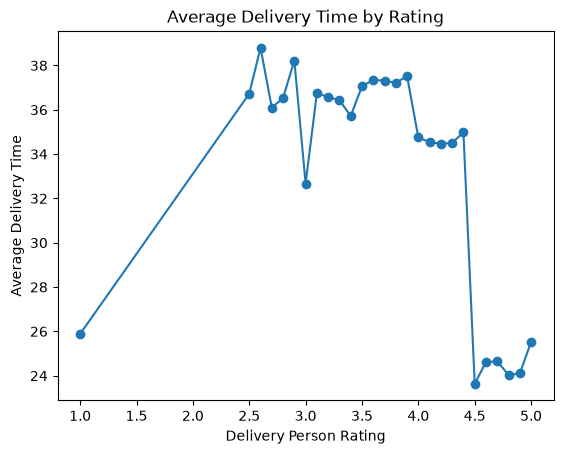

In [1339]:
plt.plot(rating_time.index, rating_time.values, marker="o")
plt.xlabel("Delivery Person Rating")
plt.ylabel("Average Delivery Time")
plt.title("Average Delivery Time by Rating")
plt.show()

 Remaining Data Cleaning

Time_Orderd → 1600 missing values

  Festival → 215 missing values

  City → 1114 missing values

  Delivery_person_Age → suspicious values: 15, 50

  Delivery_person_Ratings → invalid value: 6.0

In [1340]:
print(df["Time_Orderd"].head())
print(df["Time_Orderd"].dtype)

0   1900-01-01 11:33:33
1   1900-01-01 19:45:37
2   1900-01-01 08:32:58
3   1900-01-01 18:03:58
4   1900-01-01 13:34:16
Name: Time_Orderd, dtype: datetime64[us]
datetime64[us]


In [1341]:
print(df[df["Time_Orderd"].isnull()]["Time_Order_picked"].head(10))

Series([], Name: Time_Order_picked, dtype: datetime64[us])


In [1342]:
print(df["Time_Orderd"].value_counts().head(20))

Time_Orderd
1900-01-01 20:32:38    8
1900-01-01 19:56:41    8
1900-01-01 19:21:37    7
1900-01-01 21:16:49    7
1900-01-01 19:02:56    7
1900-01-01 22:59:06    7
1900-01-01 17:37:32    7
1900-01-01 23:31:23    7
1900-01-01 21:42:35    7
1900-01-01 18:11:06    7
1900-01-01 17:16:21    7
1900-01-01 20:56:04    7
1900-01-01 22:22:11    7
1900-01-01 18:31:11    7
1900-01-01 19:59:00    6
1900-01-01 21:54:39    6
1900-01-01 20:59:04    6
1900-01-01 17:14:48    6
1900-01-01 20:45:03    6
1900-01-01 23:45:15    6
Name: count, dtype: int64


In [1343]:
print(df["Order_Hour"].value_counts().sort_index())

Order_Hour
0      543
8     1695
9     1882
10    1885
11    1868
12     887
13     752
14     755
15     828
16     679
17    3988
18    4303
19    4409
20    4356
21    4470
22    4360
23    4293
Name: count, dtype: int64


more order in evening

In [1344]:
print(df[["Time_Orderd", "Time_Order_picked"]].head(10))

          Time_Orderd   Time_Order_picked
0 1900-01-01 11:33:33 1900-01-01 11:45:29
1 1900-01-01 19:45:37 1900-01-01 19:51:49
2 1900-01-01 08:32:58 1900-01-01 08:48:47
3 1900-01-01 18:03:58 1900-01-01 18:12:52
4 1900-01-01 13:34:16 1900-01-01 13:45:36
5 1900-01-01 21:23:28 1900-01-01 21:30:20
6 1900-01-01 19:19:19 1900-01-01 19:34:16
7 1900-01-01 17:29:18 1900-01-01 17:31:55
8 1900-01-01 20:56:37 1900-01-01 21:06:20
9 1900-01-01 21:59:01 1900-01-01 22:10:28


checking delivery honemein time


In [1345]:
print(df[["Order_Hour", "Picked_Hour"]].head(10))

   Order_Hour  Picked_Hour
0          11           11
1          19           19
2           8            8
3          18           18
4          13           13
5          21           21
6          19           19
7          17           17
8          20           21
9          21           22


In [1346]:
print(df[df["Festival"].isnull()]["Time_taken(min)"].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Time_taken(min), dtype: float64


In [1347]:
print(df[df["Festival"].isnull()].isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
Order_Hour                     0
Picked_Hour                    0
Age_group                      0
dtype: int64


In [1348]:
print(df["Festival"].isnull().sum())

0


In [1349]:
print(df["Festival"].value_counts())

Festival
No     41131
Yes      822
Name: count, dtype: int64


In [1350]:
print(df["Festival"].unique())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [1351]:
df["Festival"] = df["Festival"].str.strip()

In [1352]:
df["Festival"] = df["Festival"].replace("NaN", "No")

In [1353]:
print(df["Festival"].value_counts(dropna=False))

Festival
No     41131
Yes      822
Name: count, dtype: int64


In [1354]:
print(df["City"].unique())

<StringArray>
['Urban', 'Metropolitian', nan, 'Semi-Urban']
Length: 4, dtype: str


In [1355]:
df["City"] = df["City"].str.strip()

In [1356]:
df["City"] = df["City"].replace("NaN", np.nan)

replace missing value with most common value 

In [1357]:
df["City"] = df["City"].fillna(df["City"].mode()[0])

In [1358]:
print(df["City"].value_counts(dropna=False))

City
Metropolitian    32525
Urban             9279
Semi-Urban         149
Name: count, dtype: int64


rating time ordered and age still pending

In [1359]:
print(df["Delivery_person_Age"].value_counts().sort_index().head(10))

Delivery_person_Age
20.0    1964
21.0    1965
22.0    2029
23.0    1939
24.0    2044
25.0    1988
26.0    1988
27.0    1973
28.0    2004
29.0    2020
Name: count, dtype: int64


In [1360]:
print(df["Delivery_person_Age"].value_counts().sort_index().tail(10))

Delivery_person_Age
30.0    3850
31.0    1943
32.0    2010
33.0    2014
34.0    1995
35.0    2099
36.0    2083
37.0    2047
38.0    2020
39.0    1978
Name: count, dtype: int64


In [1361]:
print(df["Delivery_person_Age"].describe())

count    41953.000000
mean        29.571807
std          5.636706
min         20.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         39.000000
Name: Delivery_person_Age, dtype: float64


In [1362]:
print((df["Delivery_person_Ratings"] == 6).sum())

0


In [1363]:
print(df["Delivery_person_Ratings"].describe())

count    41953.000000
mean         4.633802
std          0.325577
min          1.000000
25%          4.500000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64


In [1364]:
print(df["Delivery_person_Ratings"].value_counts().sort_index())

Delivery_person_Ratings
1.0      35
2.5      18
2.6      20
2.7      21
2.8      17
2.9      18
3.0       6
3.1      28
3.2      26
3.3      23
3.4      32
3.5     236
3.6     194
3.7     203
3.8     218
3.9     176
4.0     998
4.1    1323
4.2    1331
4.3    1301
4.4    1246
4.5    3067
4.6    6387
4.7    8337
4.8    6558
4.9    6468
5.0    3666
Name: count, dtype: int64


In [1365]:
print(df["Time_Orderd"].isna().sum())

0


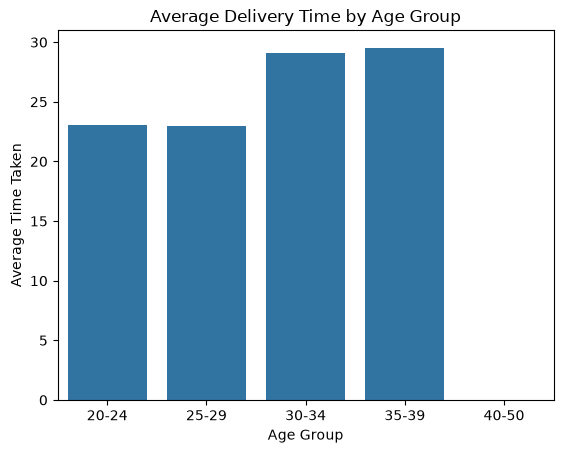

In [1366]:
sns.barplot(x="Age_group",y="Time_taken(min)",data=df,errorbar=None)
plt.xlabel("Age Group")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Age Group")
plt.show()

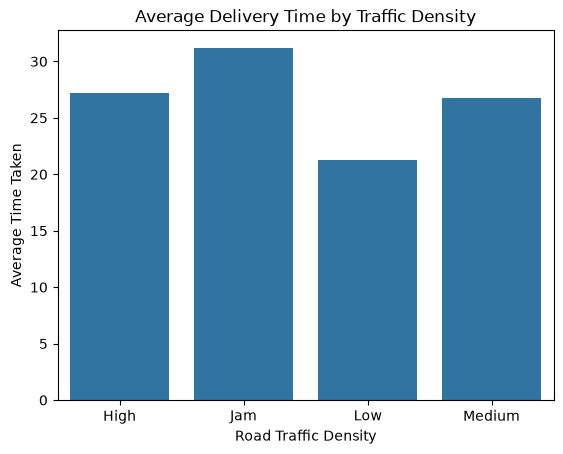

In [1367]:
sns.barplot(x="Road_traffic_density",y="Time_taken(min)",data=df,errorbar=None)
plt.xlabel("Road Traffic Density")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Traffic Density")
plt.show()

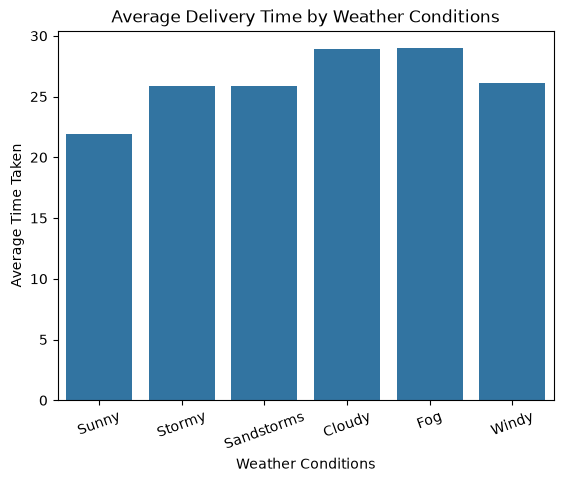

In [1368]:
sns.barplot(x="Weatherconditions",y="Time_taken(min)",data=df,errorbar=None)
plt.xlabel("Weather Conditions")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Weather Conditions")
plt.xticks(rotation=20)
plt.show()

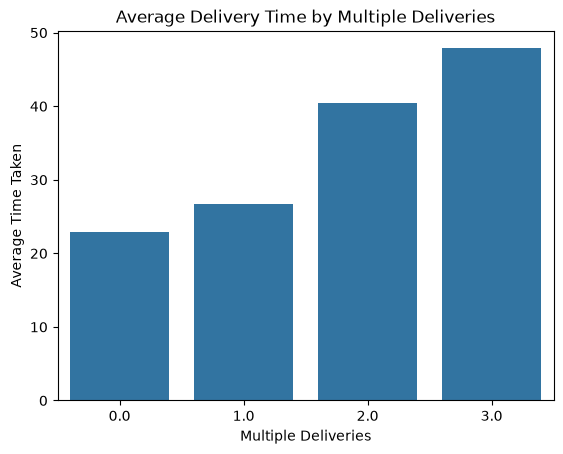

In [1369]:
sns.barplot(
    x="multiple_deliveries",
    y="Time_taken(min)",
    data=df,
    errorbar=None
)

plt.xlabel("Multiple Deliveries")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Multiple Deliveries")
plt.show()

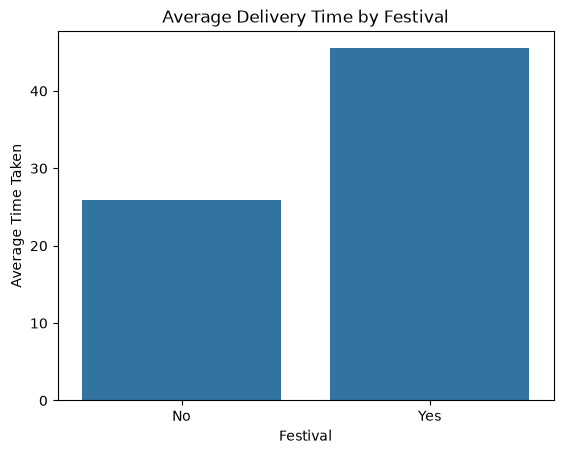

In [1370]:
sns.barplot(
    x="Festival",
    y="Time_taken(min)",
    data=df,
    errorbar=None
)

plt.xlabel("Festival")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Festival")
plt.show()

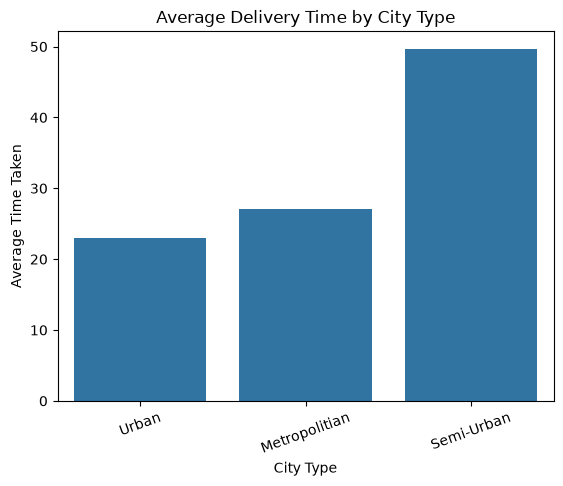

In [1371]:
sns.barplot(
    x="City",
    y="Time_taken(min)",
    data=df,
    errorbar=None
)

plt.xlabel("City Type")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by City Type")
plt.xticks(rotation=20)
plt.show()

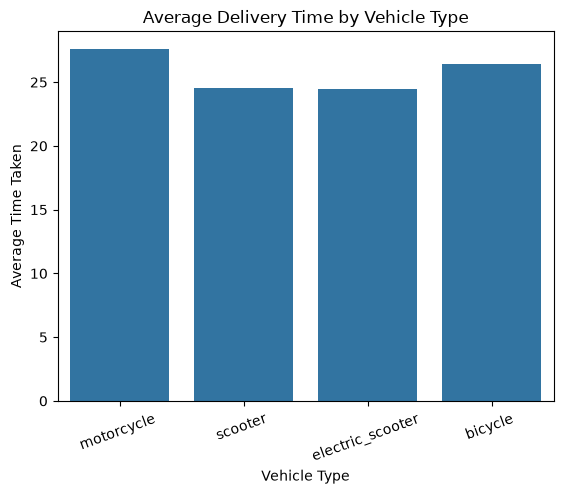

In [1372]:
sns.barplot(
    x="Type_of_vehicle",
    y="Time_taken(min)",
    data=df,
    errorbar=None
)

plt.xlabel("Vehicle Type")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Vehicle Type")
plt.xticks(rotation=20)
plt.show()

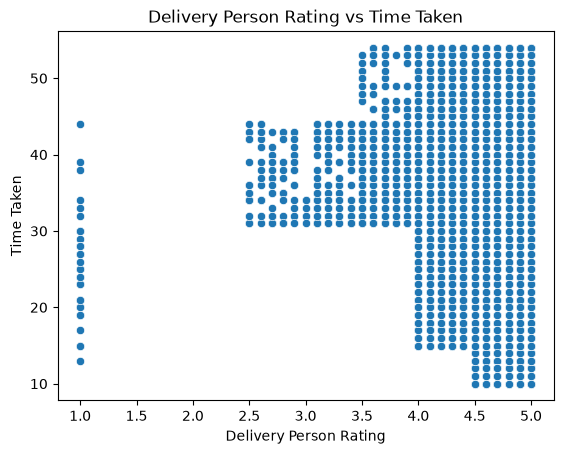

In [1373]:
sns.scatterplot(
    x="Delivery_person_Ratings",
    y="Time_taken(min)",
    data=df
)

plt.xlabel("Delivery Person Rating")
plt.ylabel("Time Taken")
plt.title("Delivery Person Rating vs Time Taken")
plt.show()

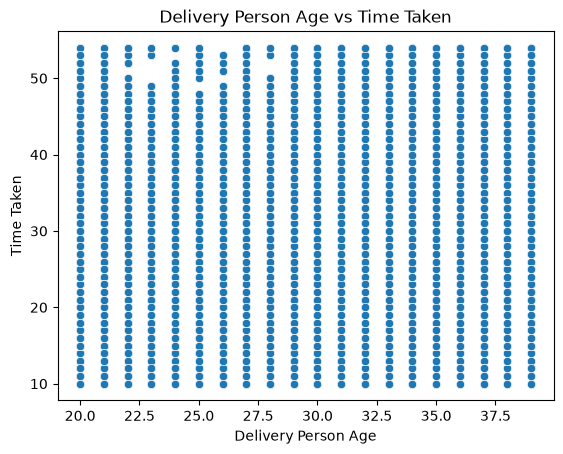

In [1374]:
sns.scatterplot(
    x="Delivery_person_Age",
    y="Time_taken(min)",
    data=df
)

plt.xlabel("Delivery Person Age")
plt.ylabel("Time Taken")
plt.title("Delivery Person Age vs Time Taken")
plt.show()

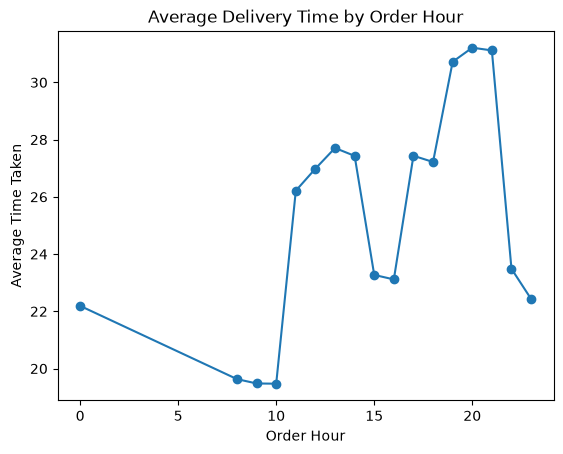

In [1375]:
hour_time = df.groupby("Order_Hour")["Time_taken(min)"].mean()

plt.plot(hour_time.index, hour_time.values, marker="o")

plt.xlabel("Order Hour")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Order Hour")
plt.show()

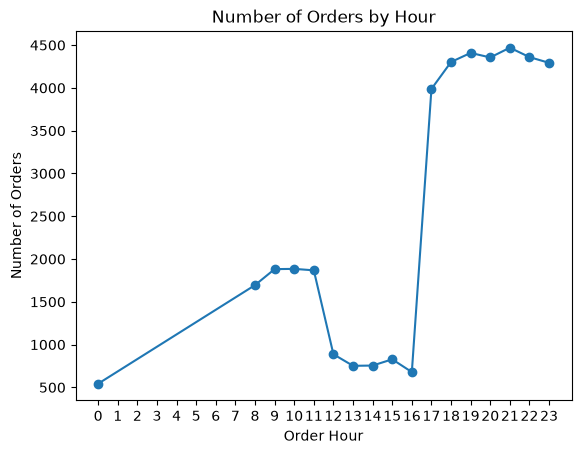

In [1376]:
order_count = df["Order_Hour"].value_counts().sort_index()

plt.plot(order_count.index, order_count.values, marker="o")

plt.xlabel("Order Hour")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Hour")
plt.xticks(range(0, 24))
plt.show()

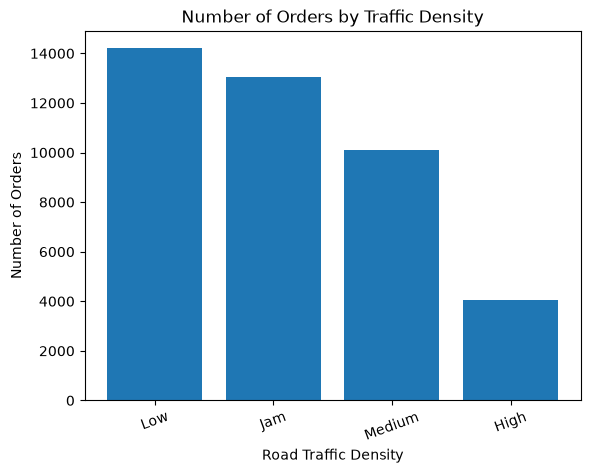

In [1377]:
traffic_count = df["Road_traffic_density"].value_counts()
plt.bar(traffic_count.index, traffic_count.values)
plt.xlabel("Road Traffic Density")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Traffic Density")
plt.xticks(rotation=20)
plt.show()

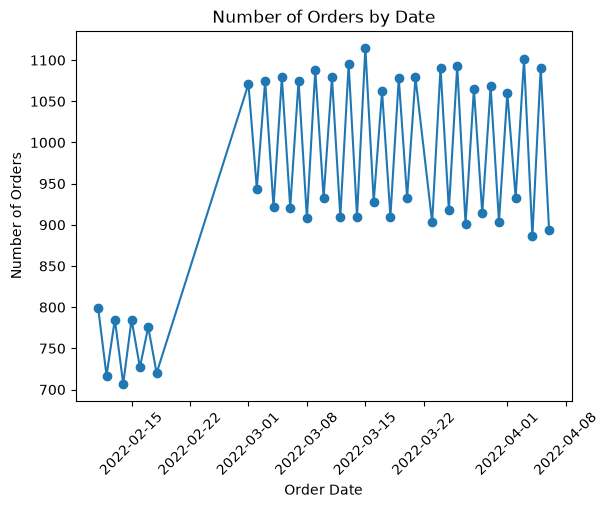

In [1378]:
date_count = df["Order_Date"].value_counts().sort_index()
plt.plot(date_count.index, date_count.values, marker="o")

plt.xlabel("Order Date")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Date")
plt.xticks(rotation=45)
plt.show()

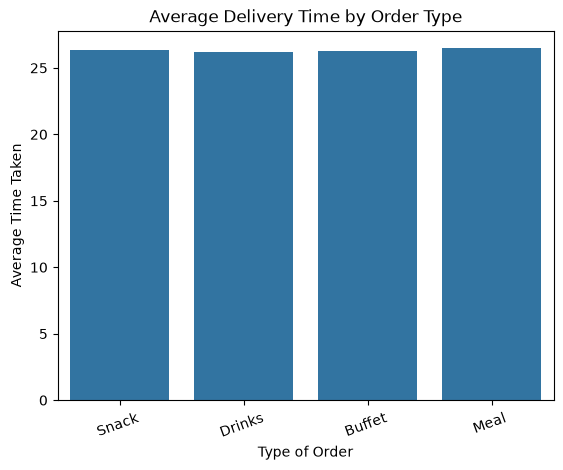

In [1379]:
sns.barplot(
    x="Type_of_order",
    y="Time_taken(min)",
    data=df,
    errorbar=None
)

plt.xlabel("Type of Order")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Order Type")
plt.xticks(rotation=20)
plt.show()

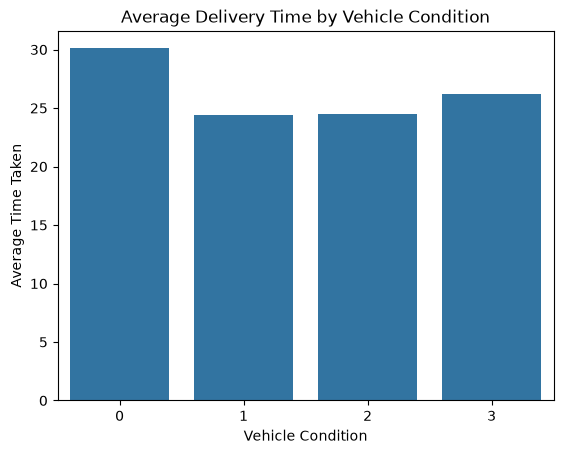

In [1380]:
sns.barplot(
    x="Vehicle_condition",
    y="Time_taken(min)",
    data=df,
    errorbar=None
)

plt.xlabel("Vehicle Condition")
plt.ylabel("Average Time Taken")
plt.title("Average Delivery Time by Vehicle Condition")
plt.show()

In [1381]:
traffic_hour = pd.crosstab(
    df["Order_Hour"],
    df["Road_traffic_density"]
)
print(traffic_hour)

Road_traffic_density  High   Jam   Low  Medium
Order_Hour                                    
0                        0     0   510       0
8                        0     0  1684       0
9                        0     0  1849       0
10                       0     0  1864       0
11                    1621     0   225       0
12                     867     0     0       0
13                     742     0     0       0
14                     748     0     0       0
15                      93     0     0     721
16                       0     0     0     671
17                       0     0     0    3960
18                       0     0     0    4244
19                       0  3860     0     488
20                       0  4303     0       0
21                       0  4411     0       0
22                       0   469  3835       0
23                       0     0  4233       0


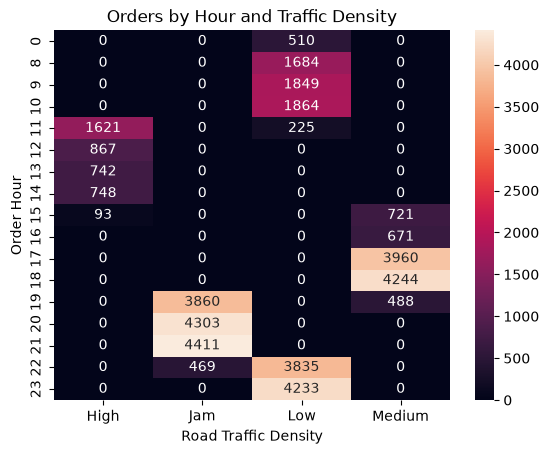

In [1382]:
sns.heatmap(traffic_hour, annot=True, fmt="d")
plt.xlabel("Road Traffic Density")
plt.ylabel("Order Hour")
plt.title("Orders by Hour and Traffic Density")
plt.show()

In [1383]:
city_traffic = pd.crosstab(
    df["City"],
    df["Road_traffic_density"]
)

print(city_traffic)

Road_traffic_density  High    Jam    Low  Medium
City                                            
Metropolitian         3186  10503  10475    7916
Semi-Urban              15    122      0      11
Urban                  870   2418   3725    2157


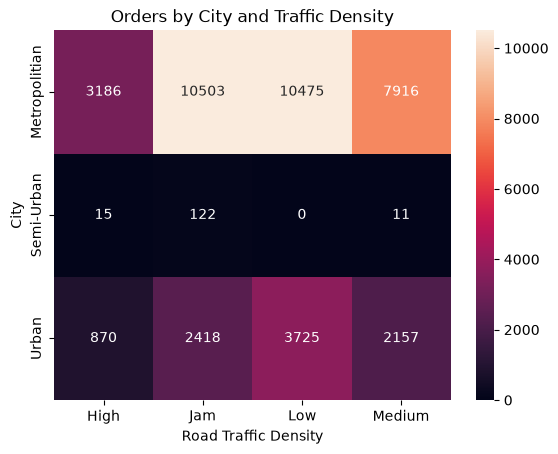

In [1384]:
sns.heatmap(city_traffic, annot=True, fmt="d")

plt.xlabel("Road Traffic Density")
plt.ylabel("City")
plt.title("Orders by City and Traffic Density")
plt.show()

In [1385]:
festival_city = pd.crosstab(
    df["City"],
    df["Festival"]
)
print(festival_city)

Festival          No  Yes
City                     
Metropolitian  31839  686
Semi-Urban       113   36
Urban           9179  100


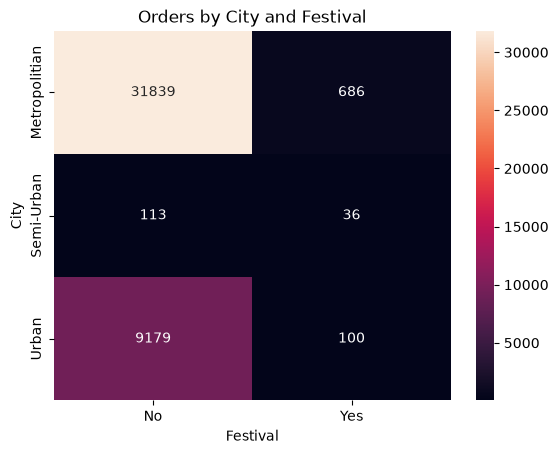

In [1386]:
sns.heatmap(festival_city, annot=True, fmt="d")
plt.xlabel("Festival")
plt.ylabel("City")
plt.title("Orders by City and Festival")
plt.show()

In [1387]:
order_vehicle = pd.crosstab(
    df["Type_of_order"],
    df["Type_of_vehicle"]
)
print(order_vehicle)

Type_of_vehicle  bicycle   electric_scooter   motorcycle   scooter 
Type_of_order                                                      
Buffet                 11                862         6085      3410
Drinks                 16                882         6029      3518
Meal                   19                847         6116      3542
Snack                  14                877         6166      3559


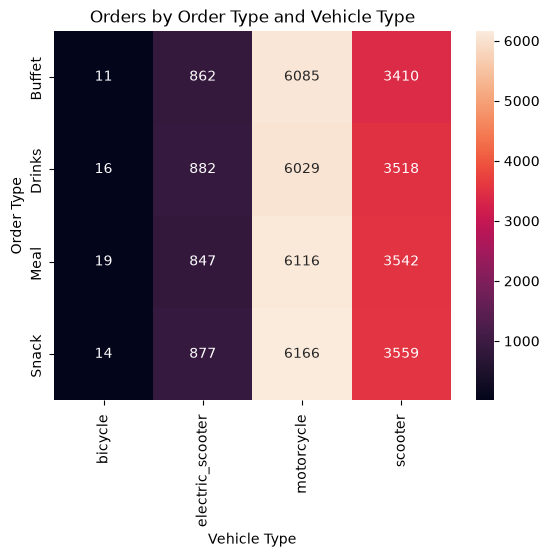

In [1388]:
sns.heatmap(order_vehicle, annot=True, fmt="d")
plt.xlabel("Vehicle Type")
plt.ylabel("Order Type")
plt.title("Orders by Order Type and Vehicle Type")
plt.show()

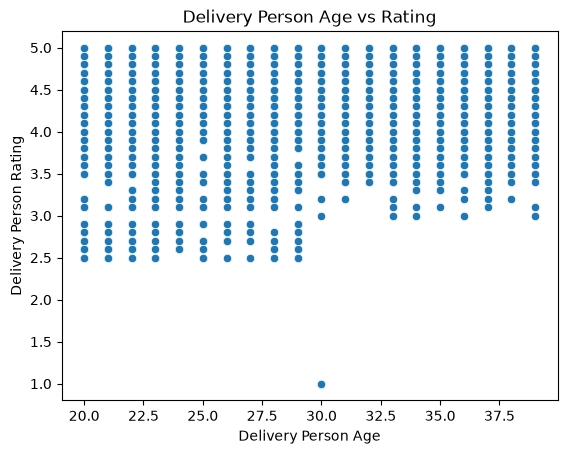

In [1389]:
sns.scatterplot(
    x="Delivery_person_Age",
    y="Delivery_person_Ratings",
    data=df
)
plt.xlabel("Delivery Person Age")
plt.ylabel("Delivery Person Rating")
plt.title("Delivery Person Age vs Rating")
plt.show()

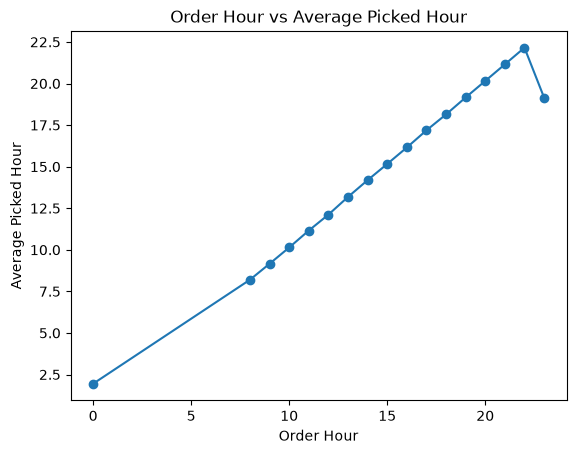

In [1390]:
hour_compare = df.groupby("Order_Hour")["Picked_Hour"].mean()
plt.plot(hour_compare.index, hour_compare.values, marker="o")
plt.xlabel("Order Hour")
plt.ylabel("Average Picked Hour")
plt.title("Order Hour vs Average Picked Hour")
plt.show()

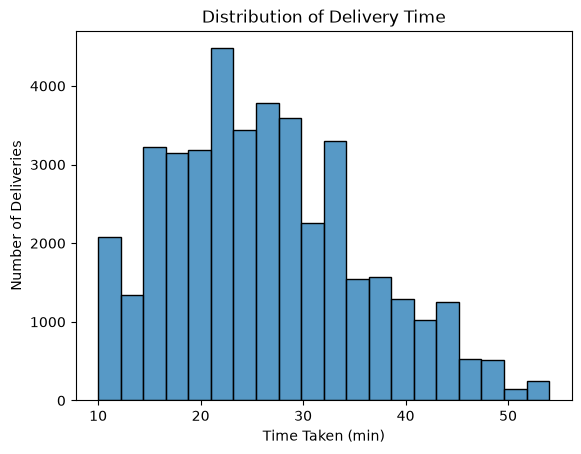

In [1391]:
sns.histplot(
    df["Time_taken(min)"],
    bins=20
)
plt.xlabel("Time Taken (min)")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Delivery Time")
plt.show()

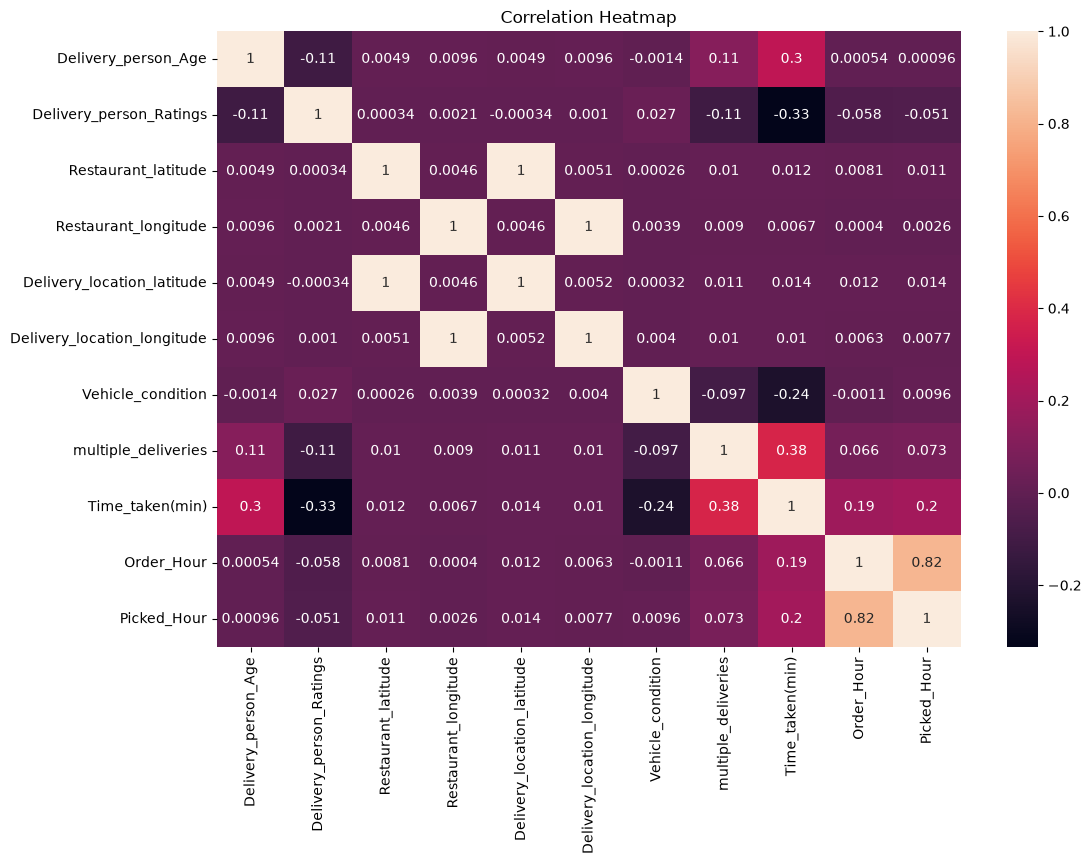

In [1392]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [1393]:
time_corr = corr["Time_taken(min)"].sort_values(ascending=False)

print(time_corr)

Time_taken(min)                1.000000
multiple_deliveries            0.377921
Delivery_person_Age            0.296254
Picked_Hour                    0.203237
Order_Hour                     0.187994
Delivery_location_latitude     0.014335
Restaurant_latitude            0.012185
Delivery_location_longitude    0.010042
Restaurant_longitude           0.006680
Vehicle_condition             -0.235016
Delivery_person_Ratings       -0.334508
Name: Time_taken(min), dtype: float64


In [1394]:
print(df["Type_of_vehicle"].value_counts())

Type_of_vehicle
motorcycle           24396
scooter              14029
electric_scooter      3468
bicycle                 60
Name: count, dtype: int64


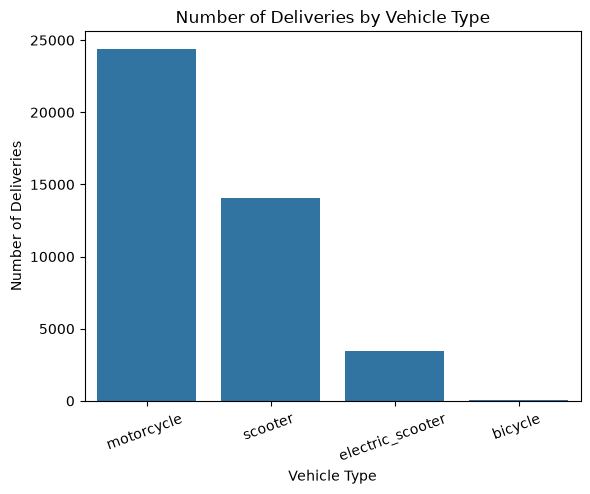

In [1395]:
sns.countplot(x="Type_of_vehicle", data=df)

plt.xlabel("Vehicle Type")
plt.ylabel("Number of Deliveries")
plt.title("Number of Deliveries by Vehicle Type")
plt.xticks(rotation=20)
plt.show()

In [1396]:
print(df["Type_of_order"].value_counts())

Type_of_order
Snack      10616
Meal       10524
Drinks     10445
Buffet     10368
Name: count, dtype: int64


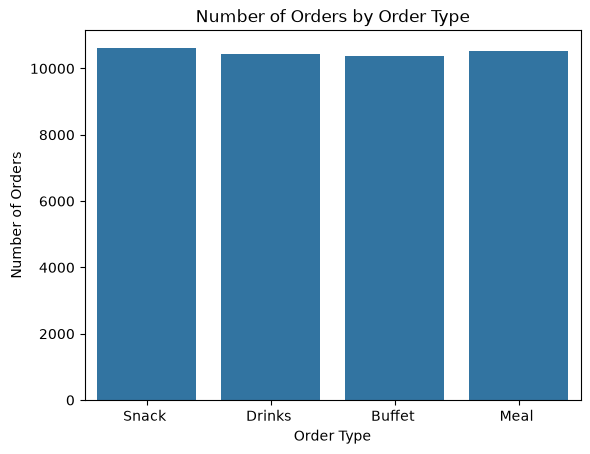

In [1397]:
sns.countplot(x="Type_of_order", data=df)

plt.xlabel("Order Type")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Order Type")
plt.show()

In [1398]:
print(df["Festival"].value_counts())

Festival
No     41131
Yes      822
Name: count, dtype: int64


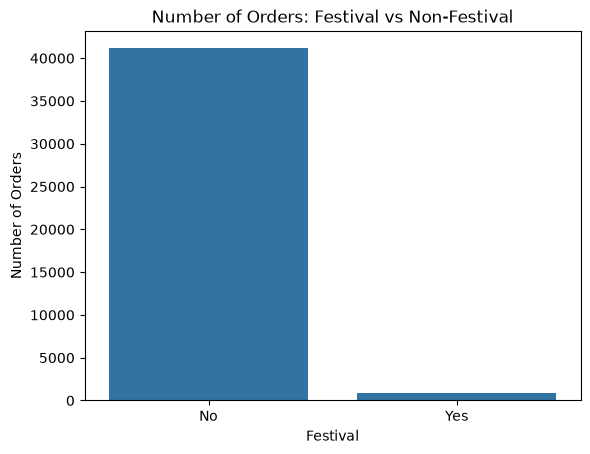

In [1399]:
sns.countplot(x="Festival", data=df)

plt.xlabel("Festival")
plt.ylabel("Number of Orders")
plt.title("Number of Orders: Festival vs Non-Festival")
plt.show()

In [1400]:
print(df["City"].value_counts())

City
Metropolitian    32525
Urban             9279
Semi-Urban         149
Name: count, dtype: int64


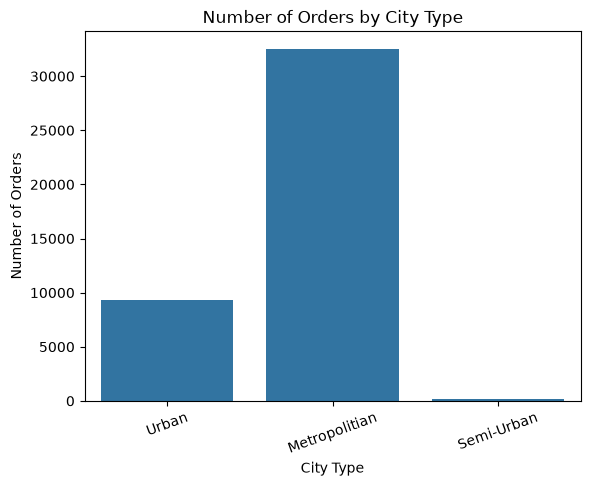

In [1401]:
sns.countplot(x="City", data=df)

plt.xlabel("City Type")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by City Type")
plt.xticks(rotation=20)
plt.show()

In [1402]:
print(df["Weatherconditions"].value_counts())

Weatherconditions
Fog           7012
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
Name: count, dtype: int64


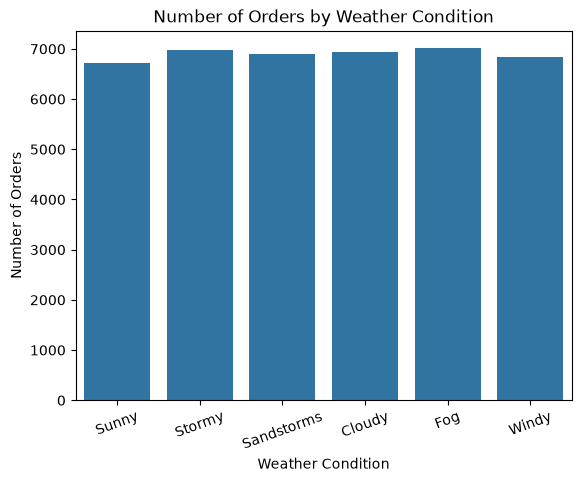

In [1403]:
sns.countplot(x="Weatherconditions", data=df)

plt.xlabel("Weather Condition")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Weather Condition")
plt.xticks(rotation=20)
plt.show()

In [1404]:
print(df["Road_traffic_density"].value_counts())

Road_traffic_density
Low       14200
Jam       13043
Medium    10084
High       4071
Name: count, dtype: int64


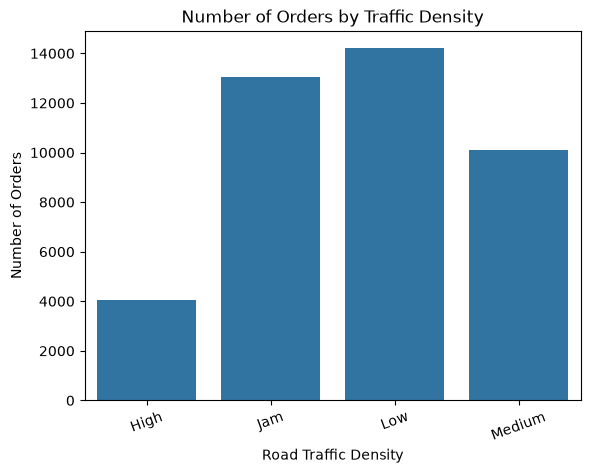

In [1405]:
sns.countplot(x="Road_traffic_density", data=df)
plt.xlabel("Road Traffic Density")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Traffic Density")
plt.xticks(rotation=20)
plt.show()

In [1406]:
print(df["Vehicle_condition"].value_counts())

Vehicle_condition
1    13851
0    13815
2    13806
3      481
Name: count, dtype: int64


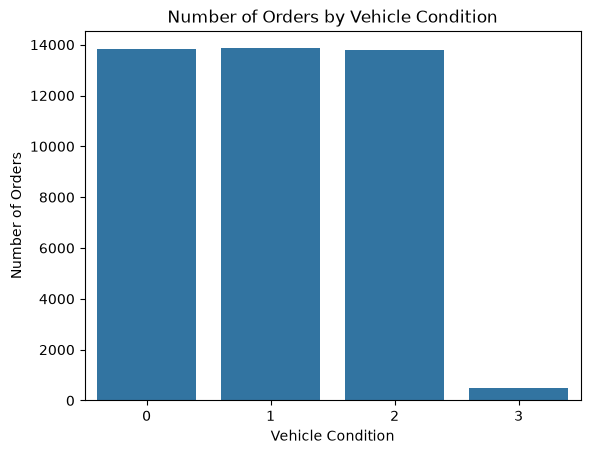

In [1407]:
sns.countplot(x="Vehicle_condition", data=df)

plt.xlabel("Vehicle Condition")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Vehicle Condition")
plt.show()

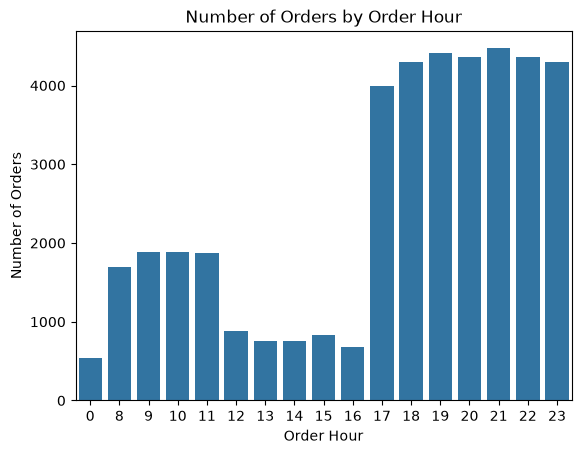

In [1408]:
sns.countplot(x="Order_Hour", data=df)

plt.xlabel("Order Hour")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Order Hour")
plt.show()

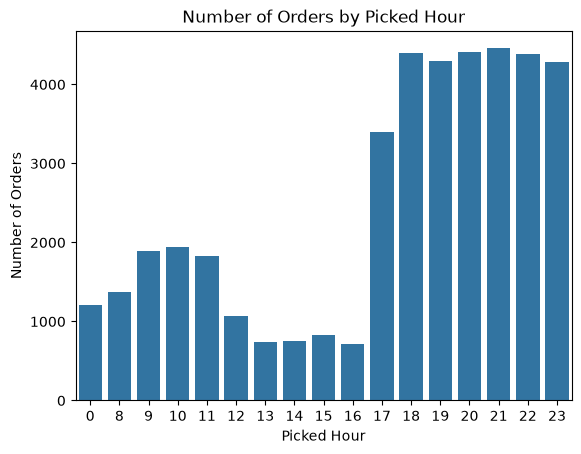

In [1409]:
sns.countplot(x="Picked_Hour", data=df)

plt.xlabel("Picked Hour")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Picked Hour")
plt.show()

Multiple deliveries increase delivery time.

 Higher traffic density is associated with higher delivery time.
 Festival orders generally take more time.

 Weather conditions affect delivery time.

 Delivery time varies across different age groups and vehicle types.

 Most orders are placed during evening hours.

 Multiple deliveries and delivery person ratings show noticeable correlation with delivery time.

In [1410]:
print(df.isnull().sum())

ID                               0
Delivery_person_ID               0
Delivery_person_Age              0
Delivery_person_Ratings          0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Orderd                      0
Time_Order_picked                0
Weatherconditions              569
Road_traffic_density           555
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries              0
Festival                         0
City                             0
Time_taken(min)                  0
Order_Hour                       0
Picked_Hour                      0
Age_group                        0
dtype: int64


In [1411]:
df["Weatherconditions"] = df["Weatherconditions"].fillna("Unknown")

In [1412]:
print(df[df["Age_group"].isna()][["Delivery_person_Age", "Age_group"]])

Empty DataFrame
Columns: [Delivery_person_Age, Age_group]
Index: []


In [1413]:
df["Age_group"] = pd.cut(
    df["Delivery_person_Age"],
    bins=[19, 24, 29, 34, 39, 50],
    labels=["20-24", "25-29", "30-34", "35-39", "40+"]
)

In [1414]:
print(df.isnull().sum())

ID                               0
Delivery_person_ID               0
Delivery_person_Age              0
Delivery_person_Ratings          0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
Order_Date                       0
Time_Orderd                      0
Time_Order_picked                0
Weatherconditions                0
Road_traffic_density           555
Vehicle_condition                0
Type_of_order                    0
Type_of_vehicle                  0
multiple_deliveries              0
Festival                         0
City                             0
Time_taken(min)                  0
Order_Hour                       0
Picked_Hour                      0
Age_group                        0
dtype: int64


In [1415]:
print(df["Road_traffic_density"].value_counts)

<bound method IndexOpsMixin.value_counts of 0          High
1           Jam
2           Low
3        Medium
4          High
          ...  
41948       Jam
41949      High
41950       Low
41951      High
41952    Medium
Name: Road_traffic_density, Length: 41953, dtype: str>


In [1416]:
df["Road_traffic_density"] = df["Road_traffic_density"].fillna("Unknown")

In [1417]:
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
Order_Hour                     0
Picked_Hour                    0
Age_group                      0
dtype: int64


In [1418]:
print(df.shape)
print(df.duplicated().sum())
print(df.isnull().sum().sum())

(41953, 23)
0
0


In [1419]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Vehicle_condition,multiple_deliveries,Time_taken(min),Order_Hour,Picked_Hour
count,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953,41953,41953,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000
mean,29.571807,4.633802,18.911397,76.923408,18.975064,76.987074,2022-03-14 04:37:32.692298,1900-01-01 17:55:53.791978,1900-01-01 17:39:51.540200,1.022716,0.750745,26.311539,17.372774,17.146116
min,20.000000,1.000000,9.957144,72.768726,9.967144,72.778726,2022-02-11 00:00:00,1900-01-01 00:00:00,1900-01-01 00:00:02,0.000000,0.000000,10.000000,0.000000,0.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,2022-03-05 00:00:00,1900-01-01 15:21:55,1900-01-01 14:37:04,0.000000,0.000000,19.000000,15.000000,14.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,2022-03-15 00:00:00,1900-01-01 19:16:48,1900-01-01 19:12:09,1.000000,1.000000,26.000000,19.000000,19.000000
75%,34.000000,4.800000,22.751234,78.368855,22.820040,78.405467,2022-03-27 00:00:00,1900-01-01 21:37:47,1900-01-01 21:37:15,2.000000,1.000000,32.000000,21.000000,21.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,1900-01-02 00:15:58.251778,1900-01-01 23:59:57,3.000000,3.000000,54.000000,23.000000,23.000000
std,5.636706,0.325577,5.467829,3.502910,5.469616,3.503073,NaN,NaN,NaN,0.838893,0.567156,9.380753,4.905809,5.321796


In [1420]:
df.to_csv("cleaned_delivery_data.csv", index=False)